Big moves on Mondays
The strategy suggests that we go long on the S&P 500 on a Monday and close our position on the friday that week on certain conditions. 
We assume that positions can be taken only in periods when markets are open from Monday to Friday in a week and the friday in the previous week.

We calculate the following indicators and backtest the conditions shown below:

1. Calculate the 25 day average of relative_range = (High - Low) / Close and call it rel_range_ma.
2. The Monday Close must be lower that the previous Friday the previous Friday Close by at least 0.25 times of rel_range_ma.
3. Create a variable ibs = (Close - Low)/(High - Low). It must be lower than 0.3.
4. If conditions in 2, and 3 are met, go long on monday Close.
5. Square off your position on Friday Close.


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
def download_daily_data(ticker, start, end):
 """ 
 The function downloads daily market data to a pandas Dataframe using yfinance API
 """
 data = yf.download(ticker, start, end, auto_adjust=False)

 if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1) #removes the ticker level
 desired_columns = ['Open','High','Low','Close','Adj Close','Volume']

 data = data[[col for col in desired_columns if col in data.columns]]

 data.columns.name = None

 return data

In [3]:
def compute_daily_returns(data):
    data['cc_returns'] = np.log(data['Close']/data['Close'].shift(1))
    return data

In [4]:
ticker1 ='SPY'
end1 = datetime.date(2026,7,31)
start1 = end1 - pd.Timedelta(days=365*15)

In [5]:
start1

datetime.date(2011, 8, 4)

In [6]:
df = download_daily_data(ticker=ticker1, start= start1, end= end1)

[*********************100%***********************]  1 of 1 completed


In [7]:
df.shape

(3768, 6)

In [8]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-08-04,124.419998,124.620003,120.059998,120.260002,92.365425,520721800
2011-08-05,121.760002,122.070000,116.860001,120.080002,92.227188,655619200
2011-08-08,116.910004,120.120003,112.019997,112.260002,86.221031,702263900
2011-08-09,114.070000,117.639999,110.269997,117.480003,90.230270,717828700
2011-08-10,115.260002,116.279999,111.949997,112.290001,86.244072,662607400


In [9]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-07-24,738.510010,743.719971,737.289978,738.929993,738.929993,44782000
2026-07-27,744.909973,745.530029,735.869995,739.090027,739.090027,41461200
2026-07-28,739.190002,742.789978,735.979980,740.859985,740.859985,47322200
2026-07-29,739.969971,742.679993,729.099976,729.460022,729.460022,70697200
2026-07-30,736.049988,742.450012,734.590027,741.690002,741.690002,66811300


In [10]:
df1a= df.copy()

In [11]:
df1a= compute_daily_returns(data=df1a)

In [12]:
df1a.head()

,Open,High,Low,Close,Adj Close,Volume,cc_returns
Date,,,,,,,
2011-08-04,124.419998,124.620003,120.059998,120.260002,92.365425,520721800,NaN
2011-08-05,121.760002,122.070000,116.860001,120.080002,92.227188,655619200,-0.001498
2011-08-08,116.910004,120.120003,112.019997,112.260002,86.221031,702263900,-0.067341
2011-08-09,114.070000,117.639999,110.269997,117.480003,90.230270,717828700,0.045451
2011-08-10,115.260002,116.279999,111.949997,112.290001,86.244072,662607400,-0.045183


In [13]:
compute_indicators?

Object `compute_indicators` not found.


In [14]:
def compute_indicators(data):
    """
    The function creates additional colums to an IHLC pandas DataFrame
    """
    #Columns created to check condition 1
    data['day'] = data.index.day_name()
    data['prev_day'] = data['day'].shift(1)
    data['four_days_after'] = data['day'].shift(-4)

    #Columns created to check condition 2
    data['relative_range']= (data['High']-data['Low'])/data['Close']
    data['rel_range_ma'] = data['relative_range'].rolling(window=25).mean()

    #Column created to check condition 3 
    data['ibs'] = (data['Close']- data['Low'])/ ( data['High']- data['Low'])
    return data

In [15]:
compute_indicators?

Signature: compute_indicators(data)
Docstring: The function creates additional colums to an IHLC pandas DataFrame
File:      /var/folders/dd/8370rq0n2d37h6bmq1n_z03m0000gn/T/ipykernel_24535/3328596577.py
Type:      function

In [16]:
def backtest_strategy(data):
    """
    The function creates additional columns to the pandas DataFrame for checking conditions
    to backtest th "Big Moves on Monday" trading strategy.
    To be run only after compute_indicators.
    """
    data['condition1']= np.where((data['day']=='Monday')
                            &(data['prev_day']=='Friday')
                            &(data['four_days_after']=='Friday'), 1, 0)
        
    data['condition2'] = np.where((1-data['Close'] / data['Close'].shift(1))
                                    >= 0.25*data['rel_range_ma'], 1, 0)

    data['condition3'] = np.where(data['ibs'] < 0.3, 1, 0)

    data['signal'] = np.where((data['condition1']==1)
                             &(data['condition2']==1)
                             &(data['condition3']==1),
                             1,0)

#The below two statements ensures that we can directly calculate strategy returns by multipling the columns 'positions' and 'cc_returns'
    data['signal']= data['signal'].shift(1)
    data['position']= data['signal'].replace(to_replace=0,value=np.nan).ffill(limit=3)
    data['position'] = data['position'].fillna(0)
    data['strategy_returns']=data['cc_returns']*data['position']
    return data  

In [17]:
df1a = compute_indicators(df1a)

In [18]:
df1a.tail()

,Open,High,Low,Close,Adj Close,Volume,cc_returns,day,prev_day,four_days_after,relative_range,rel_range_ma,ibs
Date,,,,,,,,,,,,,
2026-07-24,738.510010,743.719971,737.289978,738.929993,738.929993,44782000,0.001015,Friday,Thursday,Thursday,0.008702,0.009818,0.255057
2026-07-27,744.909973,745.530029,735.869995,739.090027,739.090027,41461200,0.000217,Monday,Friday,NaN,0.013070,0.010106,0.333335
2026-07-28,739.190002,742.789978,735.979980,740.859985,740.859985,47322200,0.002392,Tuesday,Monday,NaN,0.009192,0.010095,0.716594
2026-07-29,739.969971,742.679993,729.099976,729.460022,729.460022,70697200,-0.015507,Wednesday,Tuesday,NaN,0.018617,0.010440,0.026513
2026-07-30,736.049988,742.450012,734.590027,741.690002,741.690002,66811300,0.016627,Thursday,Wednesday,NaN,0.010597,0.010367,0.903306


In [19]:
df1a = backtest_strategy(df1a)

In [20]:
def show_backtesting_results(data):
    """
    The function displays the cumulative returns from the trading strategy and a buy-and-hold strategy.
    It also plots a chart showing both returns and position over time.
    To be run ONLY after the function backtest_strategy.
    """
    print('Buy and hold returns: ', np.round(data['cc_returns'].cumsum().iloc[-1], 2))
    print('Strategy returns: ', np.round(data['strategy_returns'].cumsum().iloc[-1], 2))

    data[['cc_returns', 'strategy_returns']] = data[['cc_returns', 'strategy_returns']].cumsum()
    data[['cc_returns', 'strategy_returns', 'position']].plot(
        secondary_y='position', grid=True, figsize=(12, 8));
    plt.show()

Buy and hold returns:  1.82
Strategy returns:  0.42


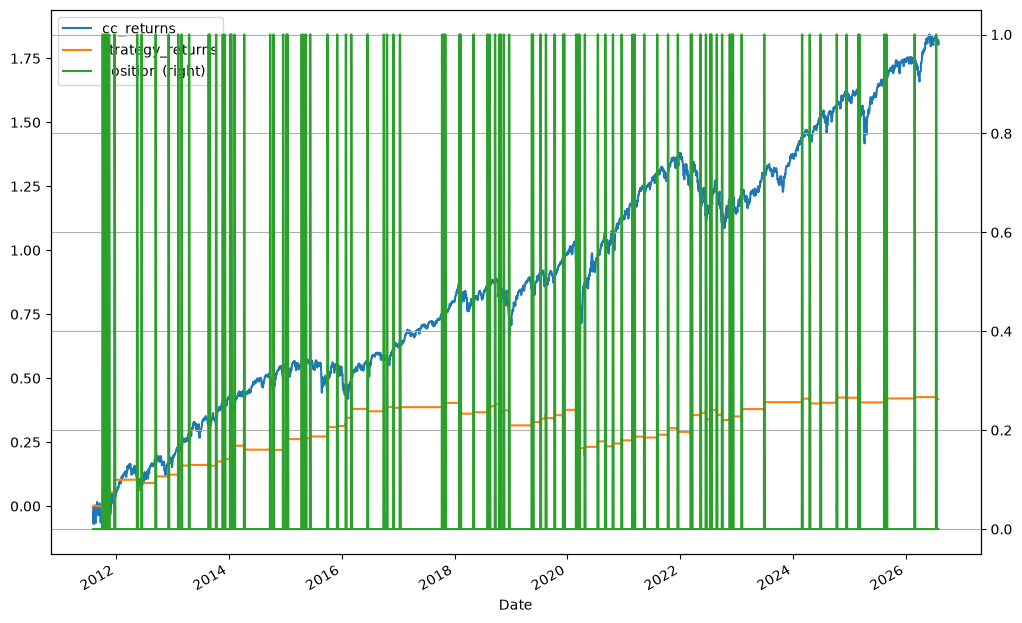

In [21]:
show_backtesting_results(df1a)

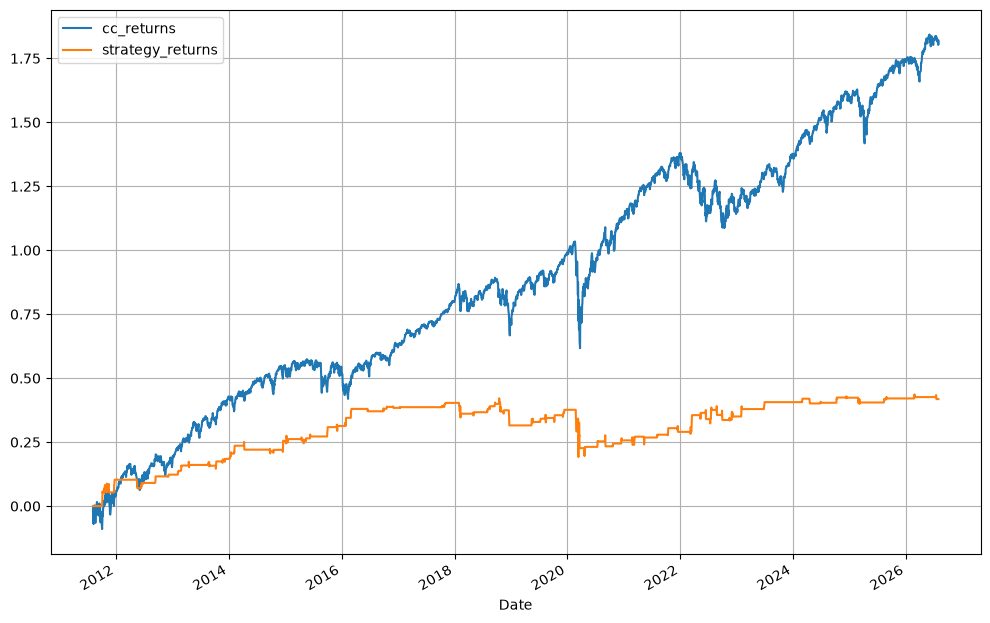

In [22]:
df1a[['cc_returns', 'strategy_returns']].plot(grid=True, figsize=(12, 8));
plt.show()